# Basic CNN for traffic sign recognition
## Christian Igel, 2022

This notebook provides a template for a small CNN for the German Traffic Sign Recognition Benchmark. The data is described in:

Johannes Stallkamp, Marc Schlipsing, Jan Salmen, and Christian Igel. Man vs. Computer: Benchmarking Machine Learning Algorithms for Traffic Sign Recognition. *Neural Networks* **32**, pp. 323-332, 2012

This notebook is a template, without modification the model does not even come close to the state-of-the-art. 

Please [contact me](mailto:igel@diku.dk) if you have suggestions for improving the notebook.

Do the imports first:

In [3]:
import os
import matplotlib.pyplot as plt
import numpy as np

import torch 
import torch.optim as optim

import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
from torch.utils.data.dataset import Dataset
from torchvision.datasets.utils import download_url, extract_archive

Check if a GPU is available:

In [5]:
gpu = torch.cuda.is_available()
device = torch.device("cuda:0" if gpu else "cpu")
print("device:", device)

device: cuda:0


The GTSRB data wrapped in a `Dataset`. This is implemented in the file `GTSRBTrafficSigns.py`. Let's import the class:

In [6]:
from GTSRBTrafficSigns import GTSRBTrafficSigns

In [7]:
dataset_train = GTSRBTrafficSigns()

100.0%


Define the data loader for training:

In [8]:
batch_size = 128
generator_train = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True, num_workers=4)

In [9]:
print("Number of training patterns:", dataset_train.__len__())

Number of training patterns: 39209


Let's visualize some input images. This visualization is very important, among others to verify that the data augmentation works as expected.

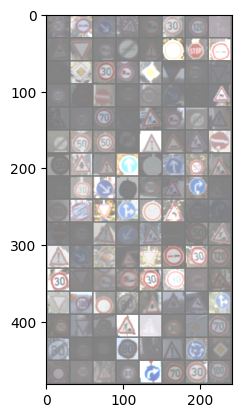

In [10]:
# functions to show an image
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(generator_train)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))

Let's look at each image in the batch with its label:

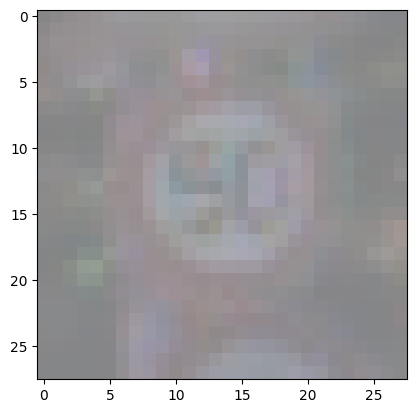

2 




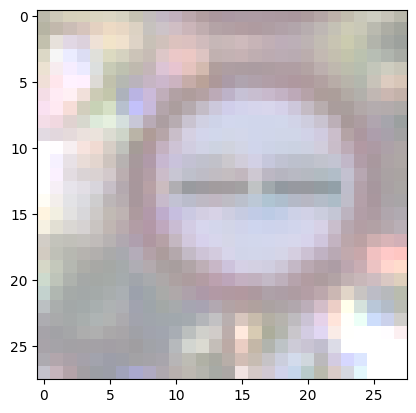

9 




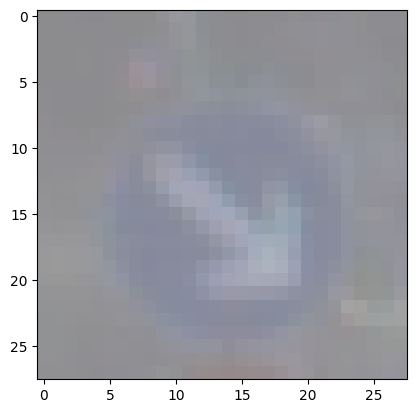

38 




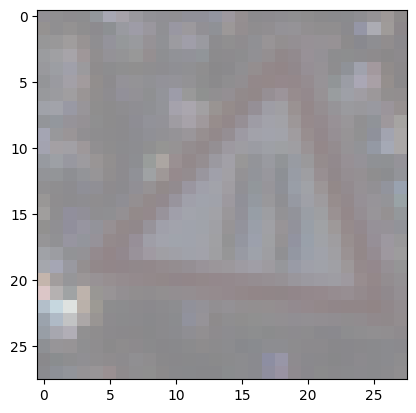

24 




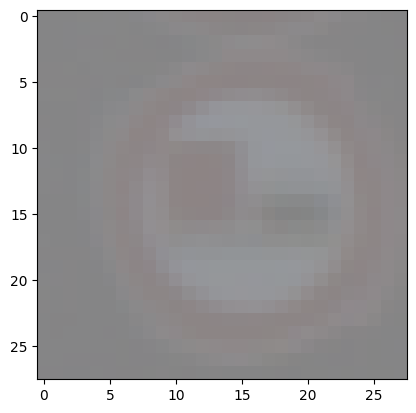

10 




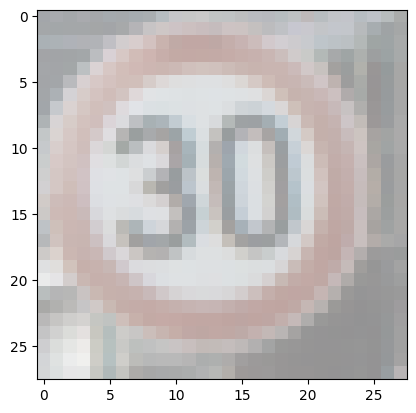

1 




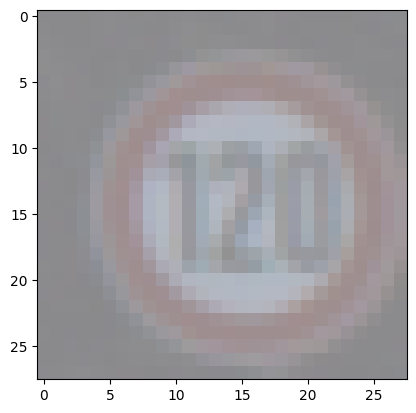

8 




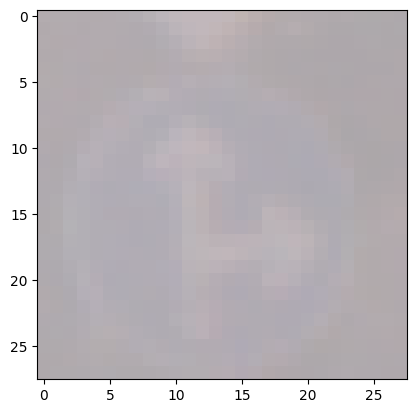

36 




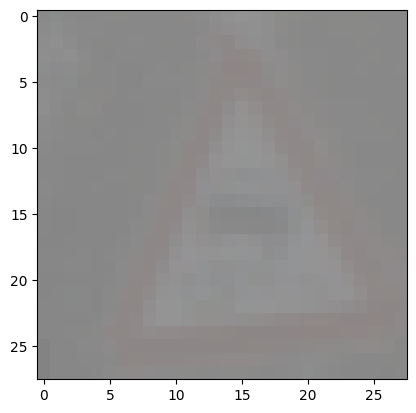

23 




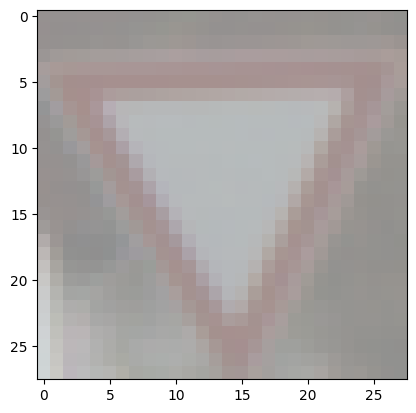

13 




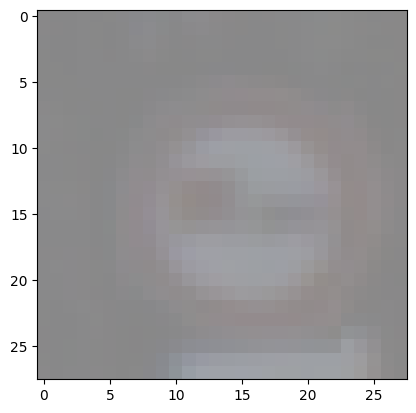

10 




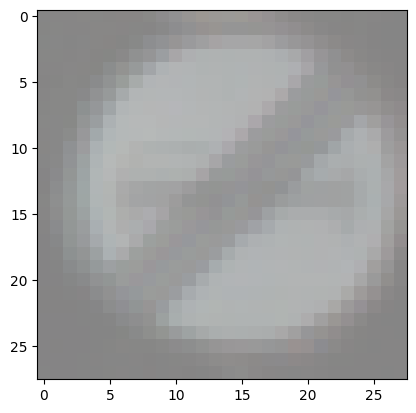

41 




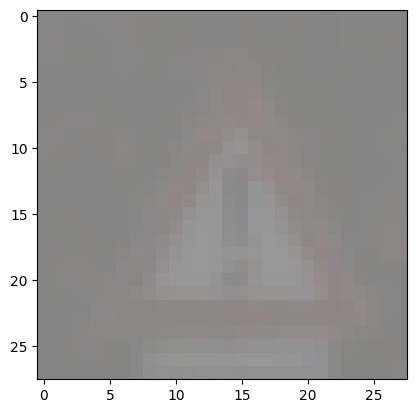

18 




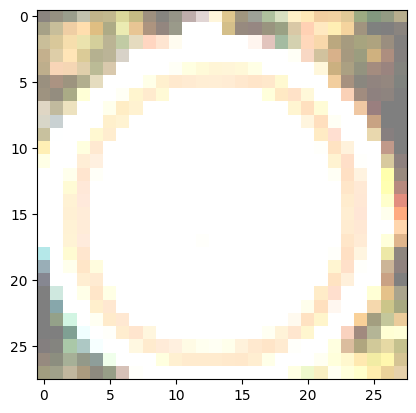

2 




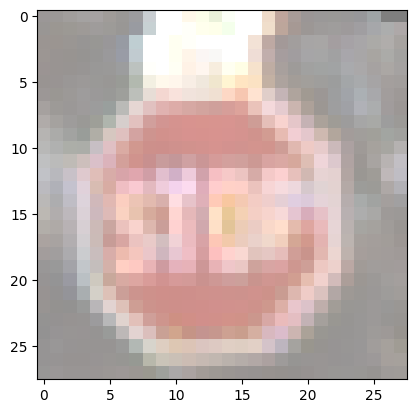

14 




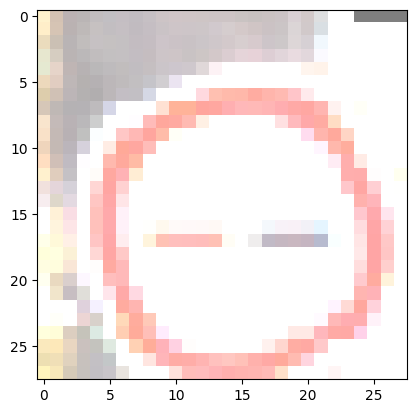

9 




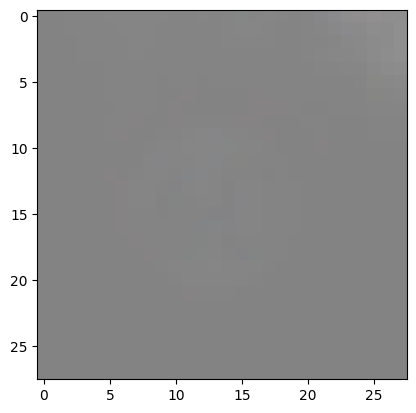

3 




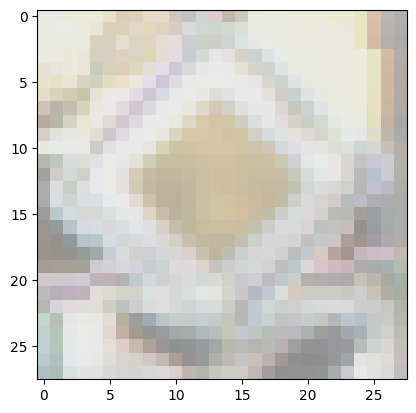

12 




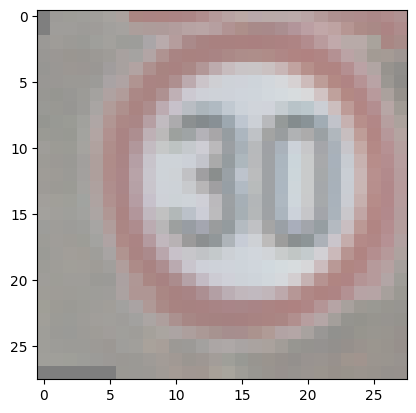

1 




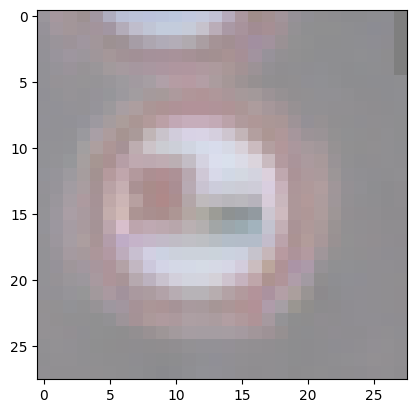

10 




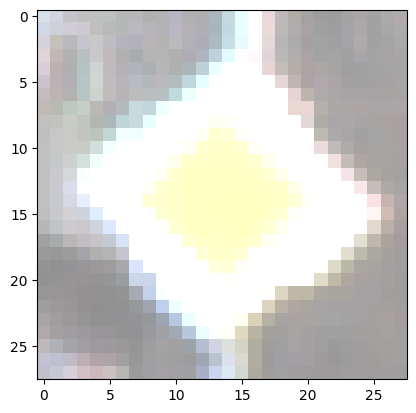

12 




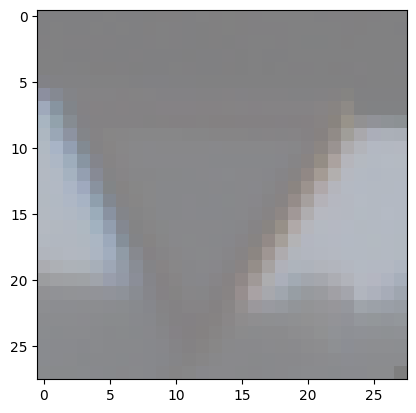

13 




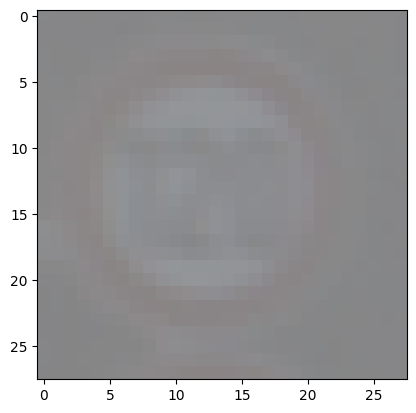

8 




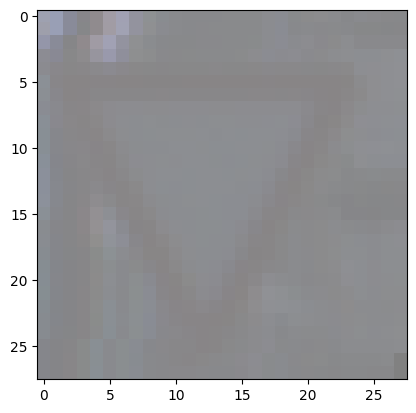

13 




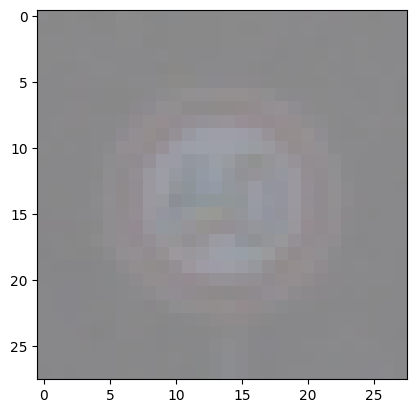

3 




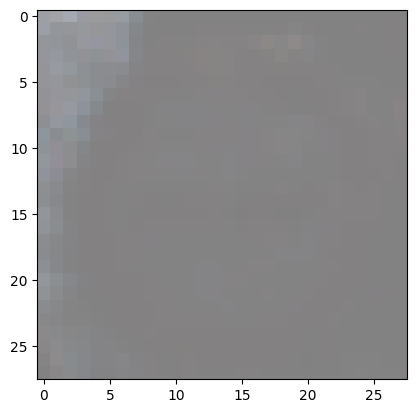

9 




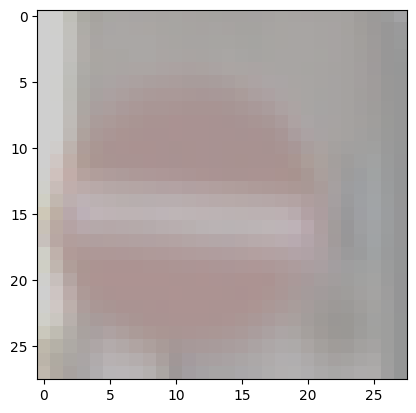

17 




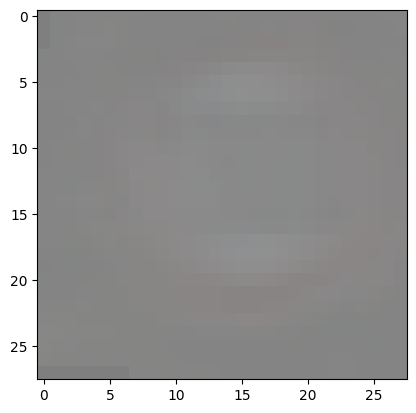

7 




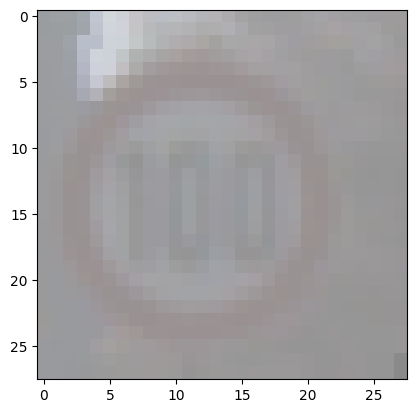

7 




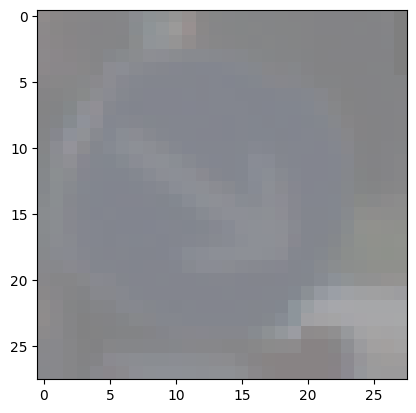

38 




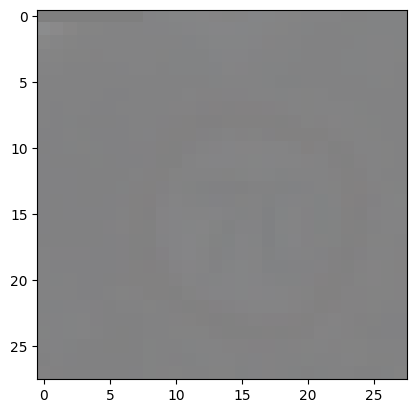

4 




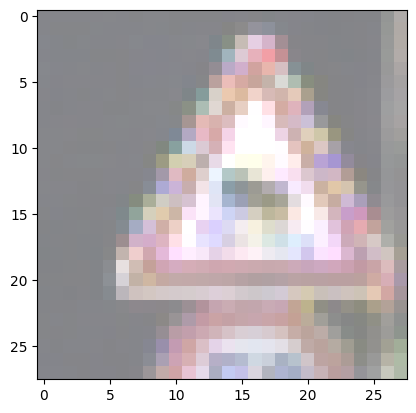

23 




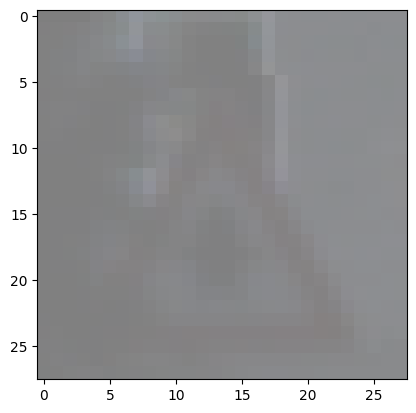

11 




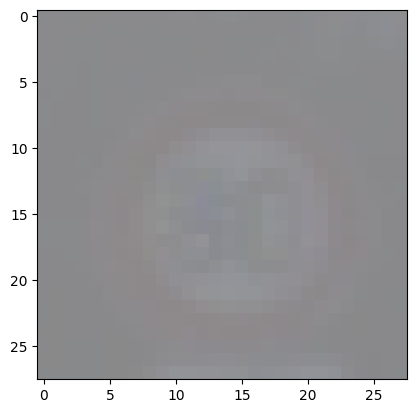

5 




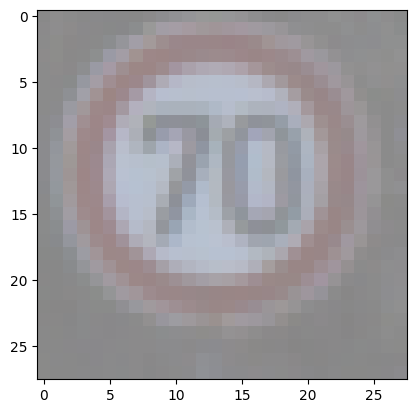

4 




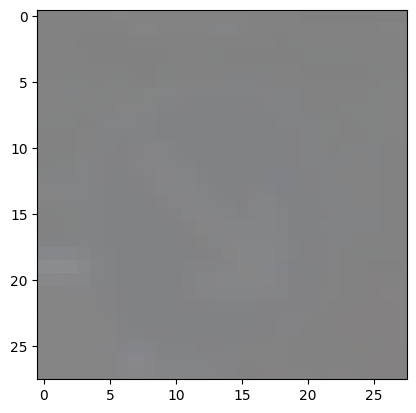

38 




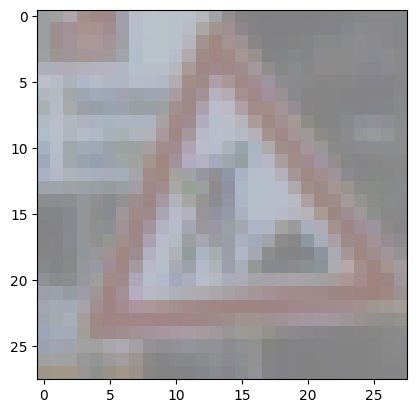

25 




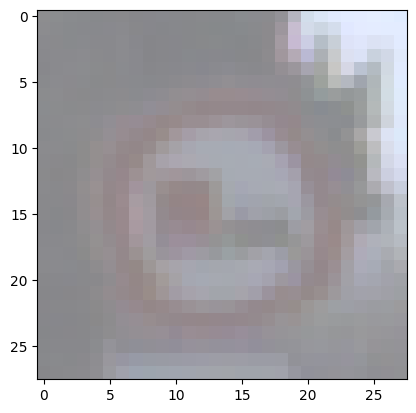

10 




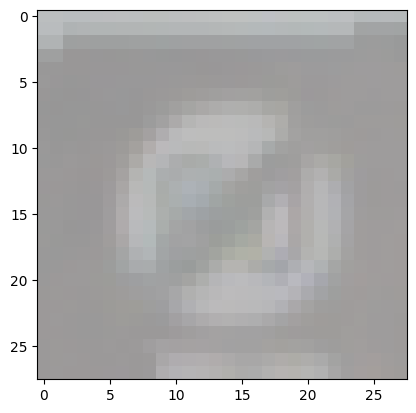

6 




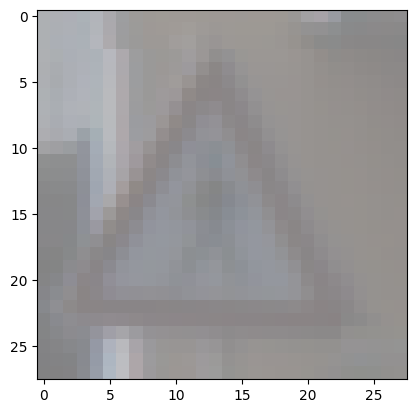

27 




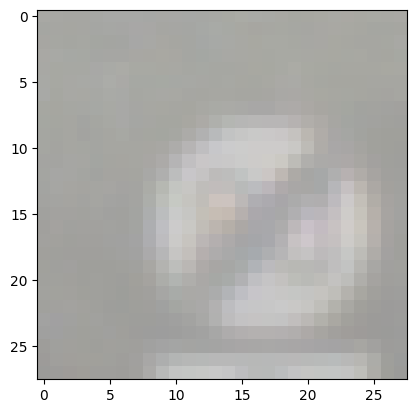

6 




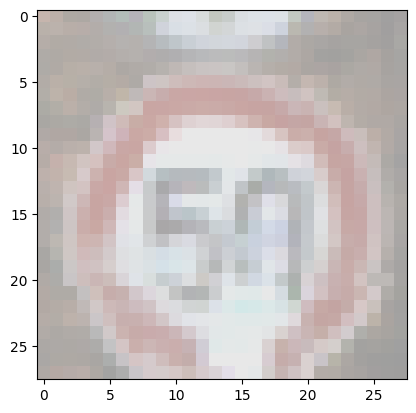

2 




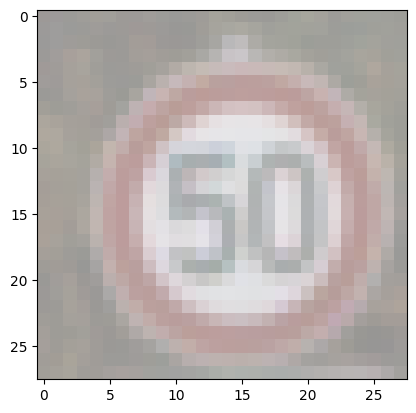

2 




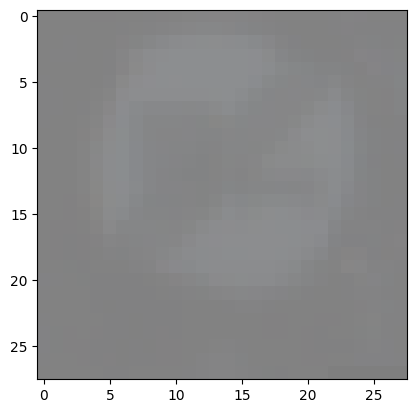

42 




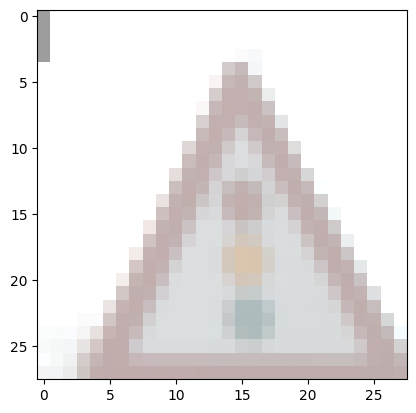

26 




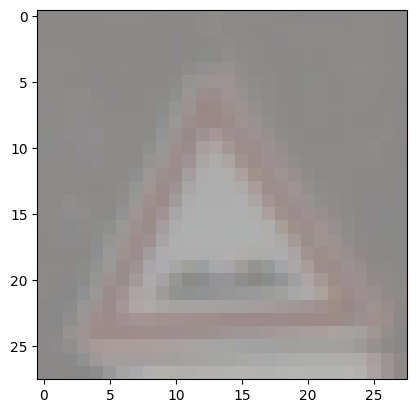

22 




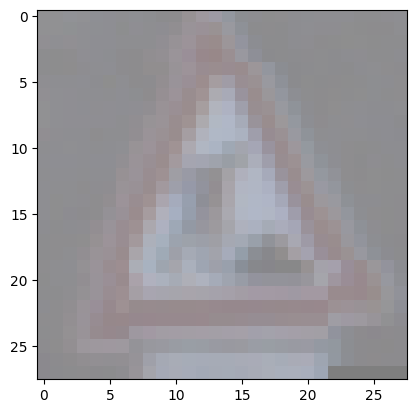

25 




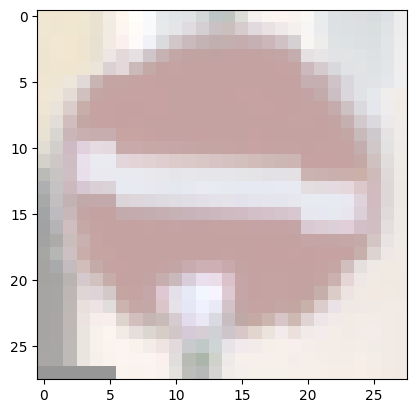

17 




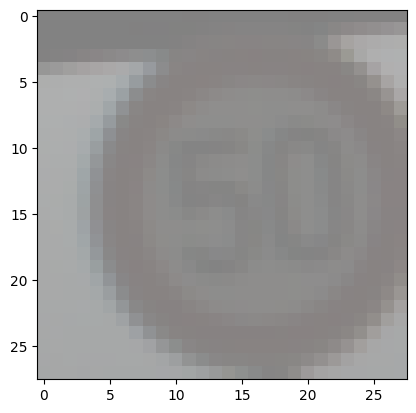

2 




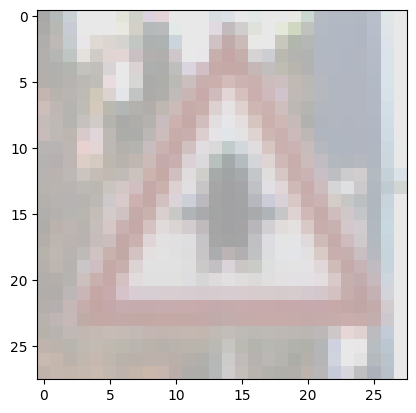

11 




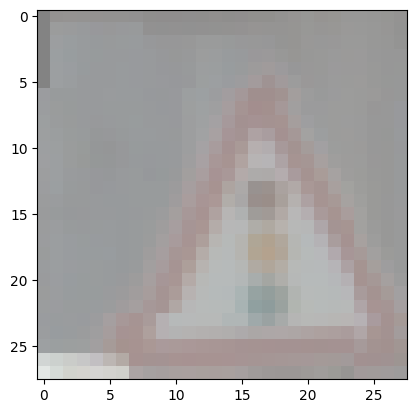

26 




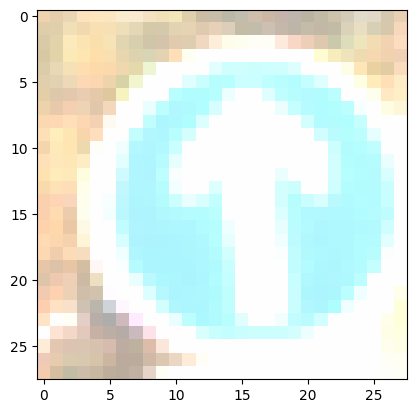

35 




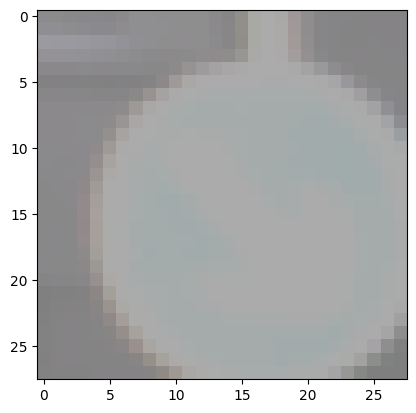

38 




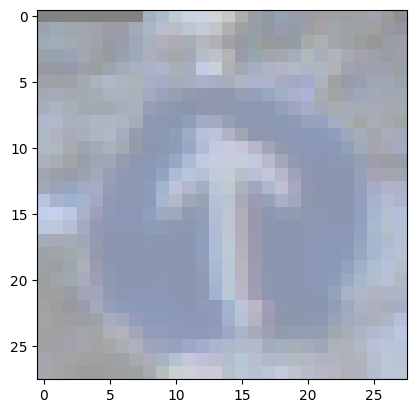

35 




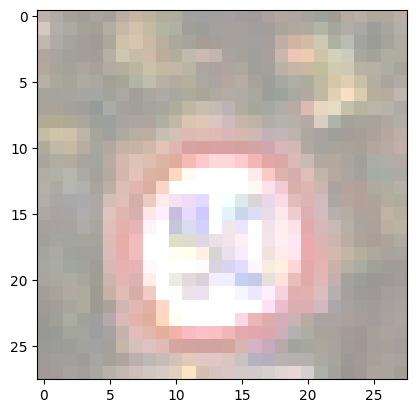

2 




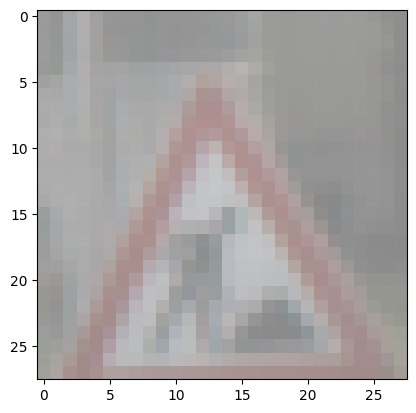

25 




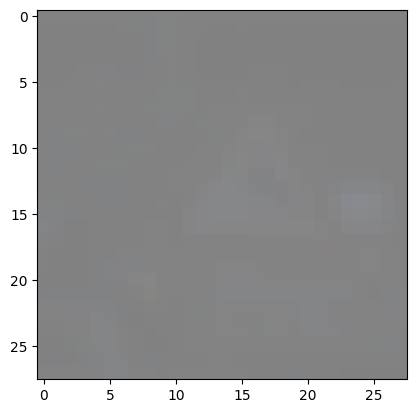

31 




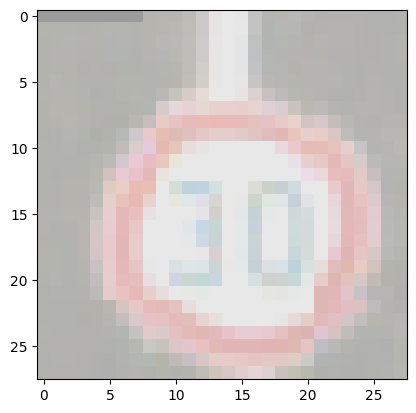

1 




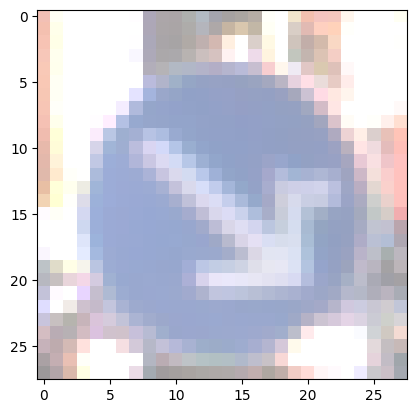

38 




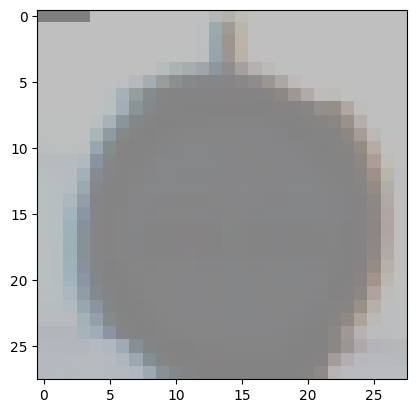

9 




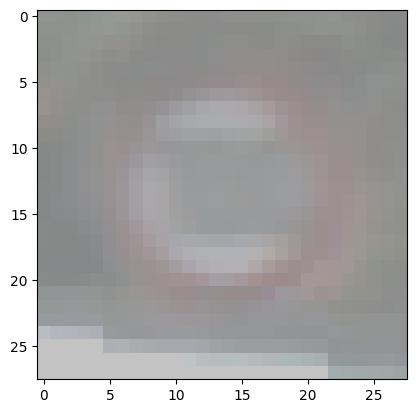

7 




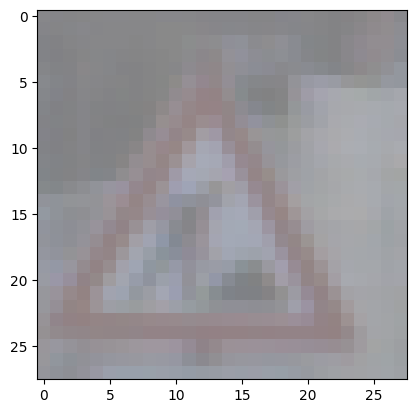

25 




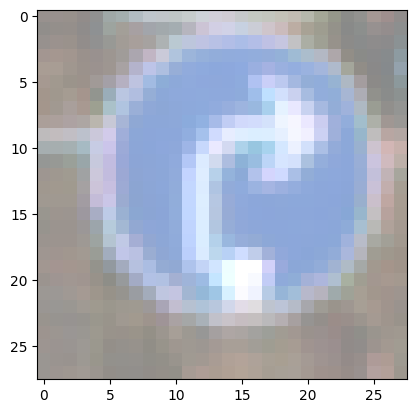

33 




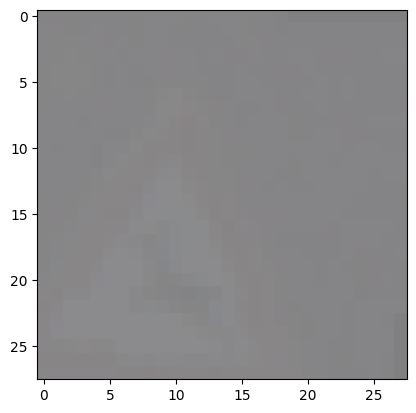

31 




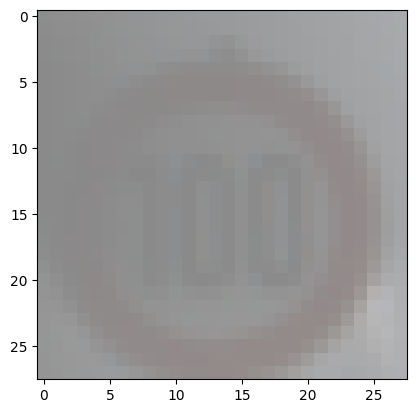

7 




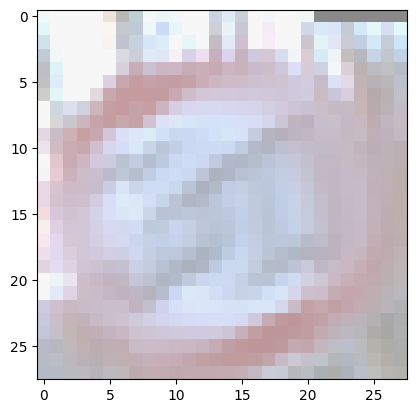

1 




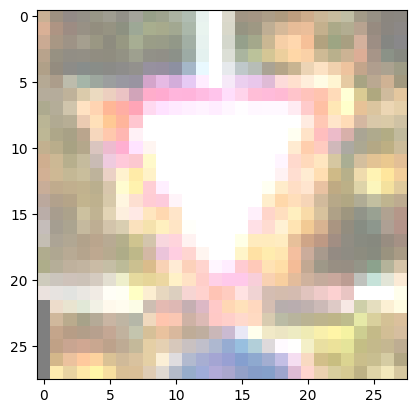

13 




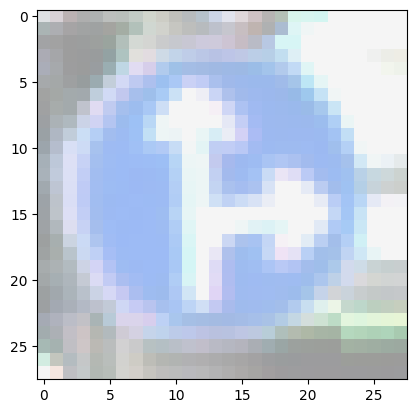

36 




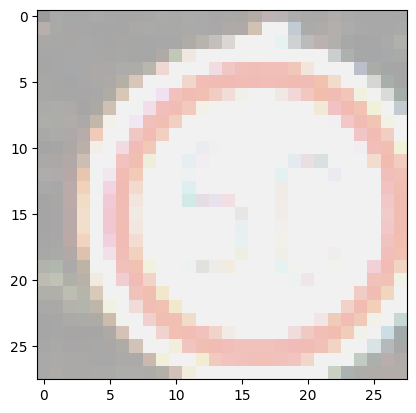

2 




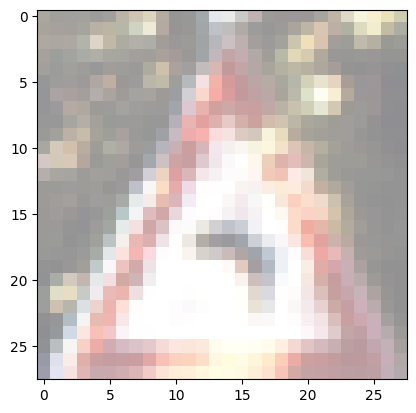

19 




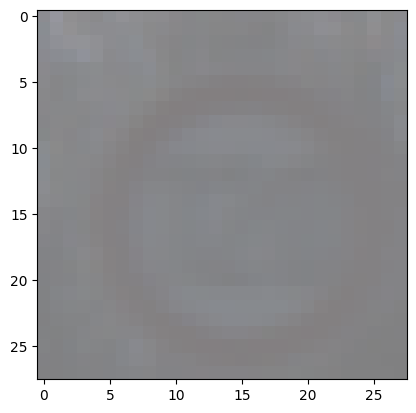

8 




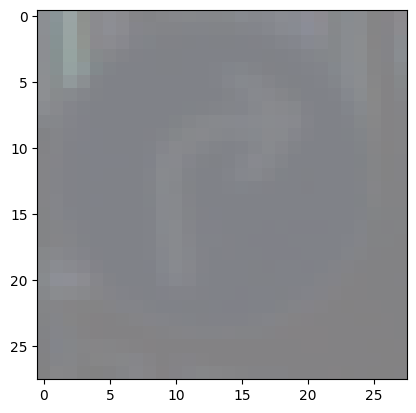

33 




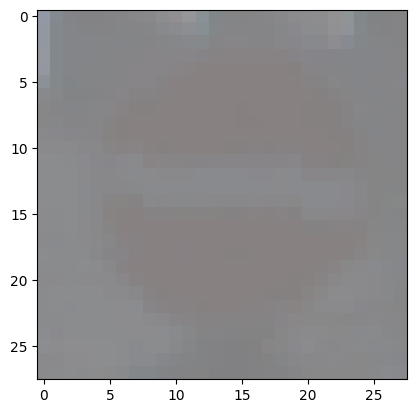

17 




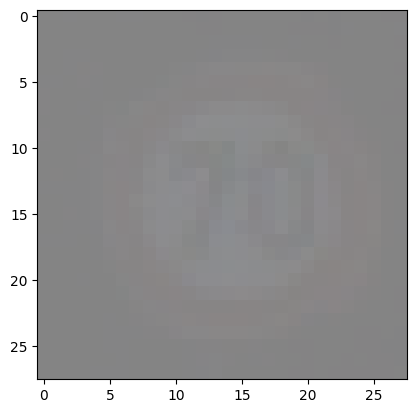

4 




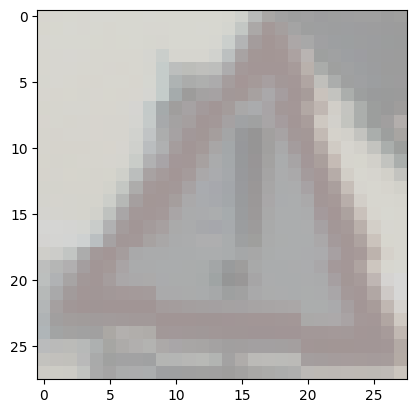

18 




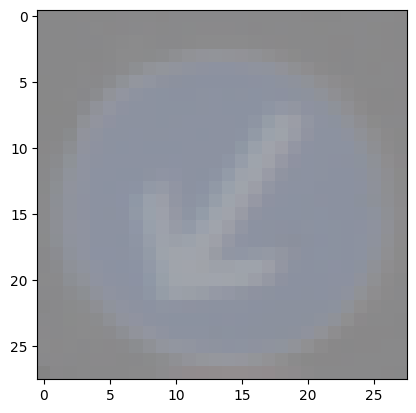

39 




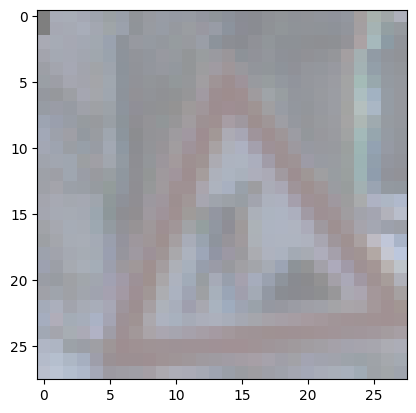

25 




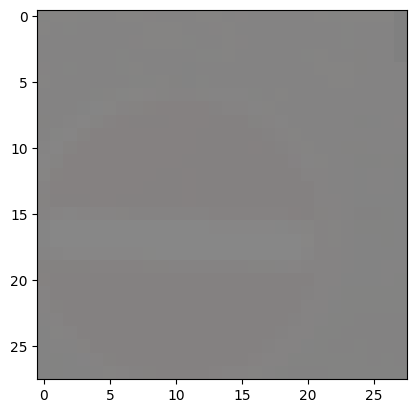

17 




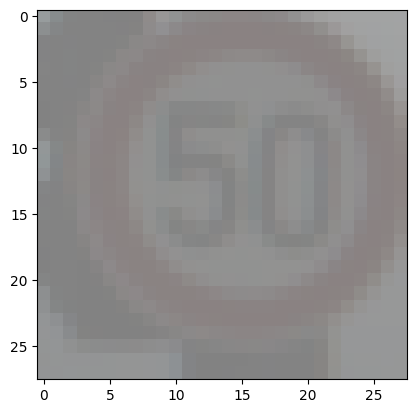

2 




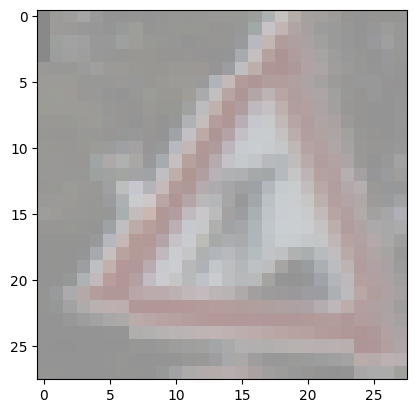

25 




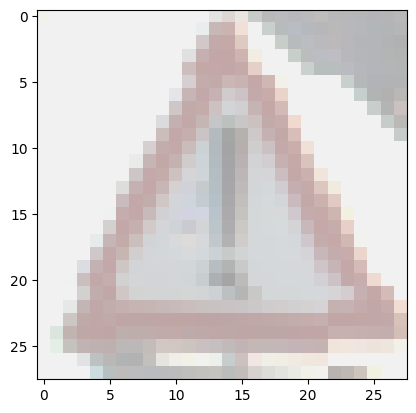

18 




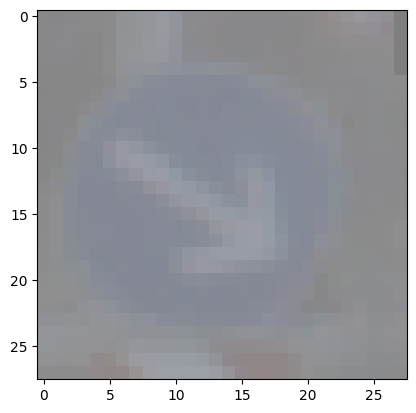

38 




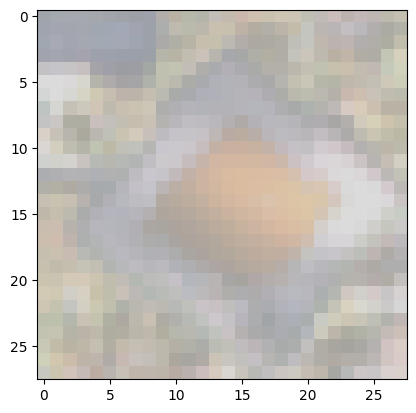

12 




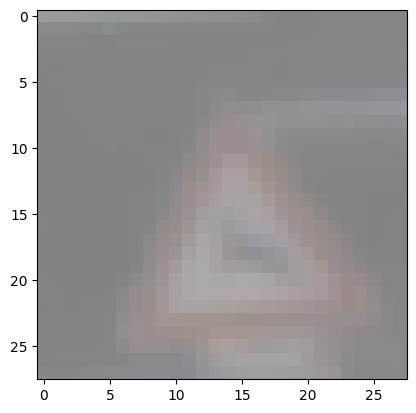

31 




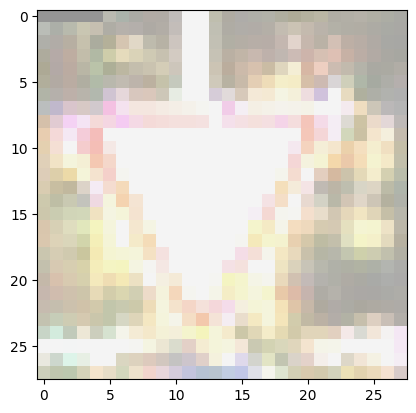

13 




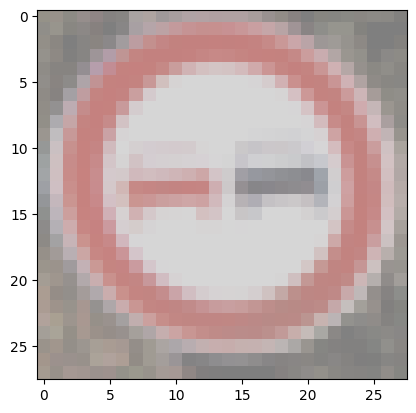

9 




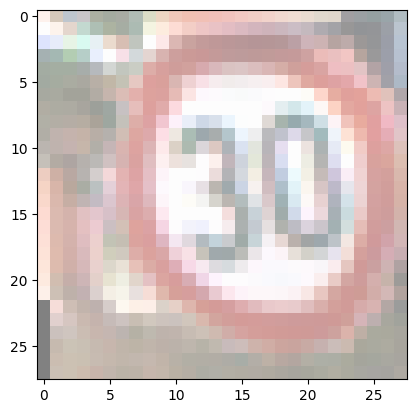

1 




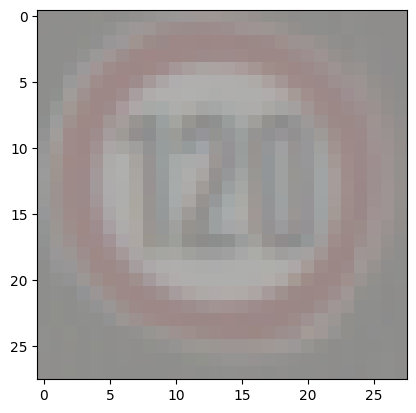

8 




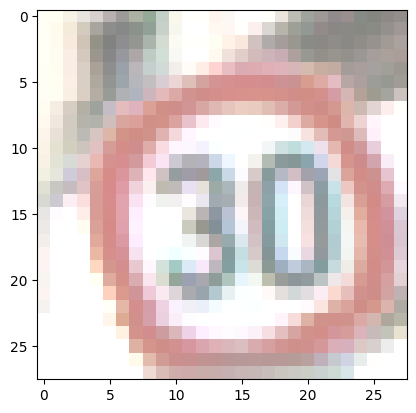

1 




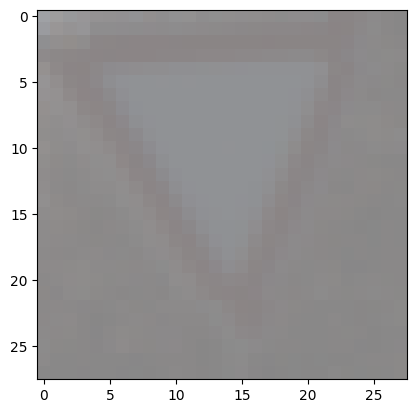

13 




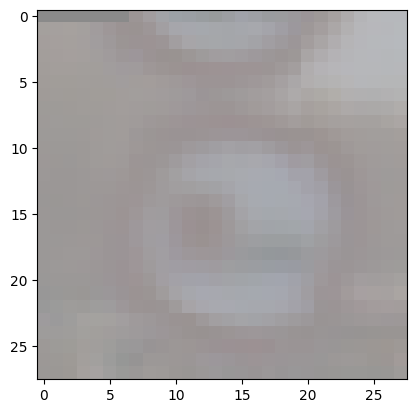

10 




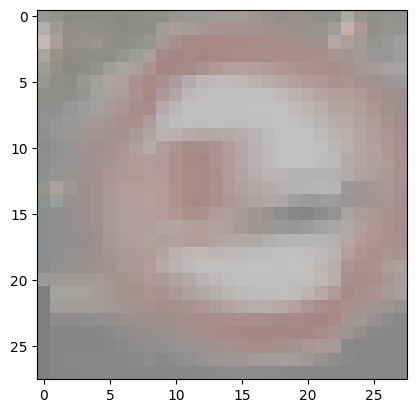

10 




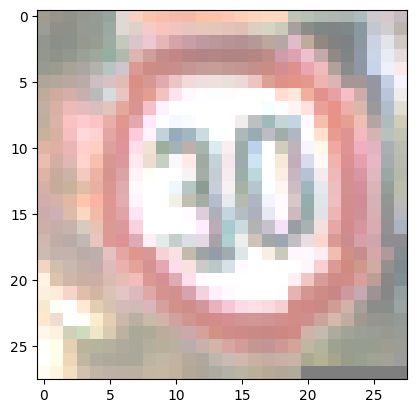

1 




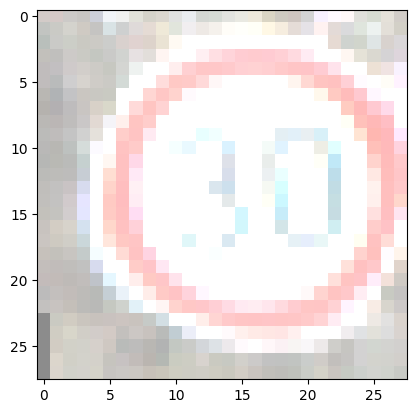

1 




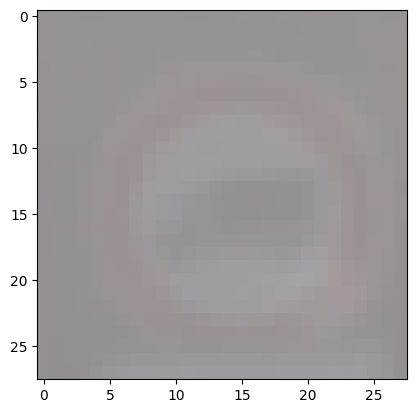

16 




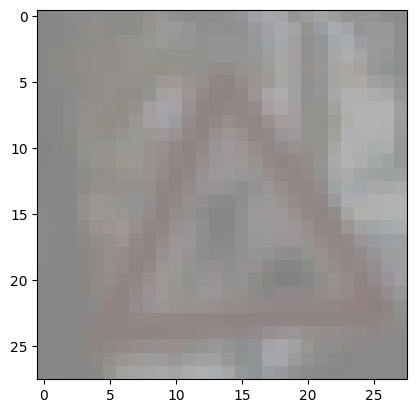

25 




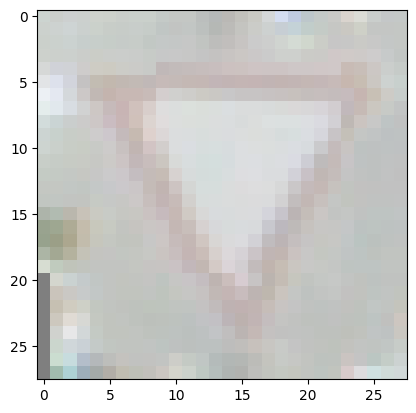

13 




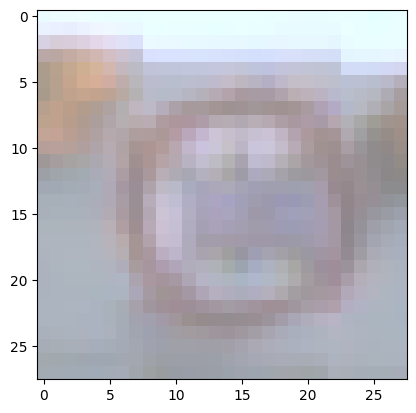

7 




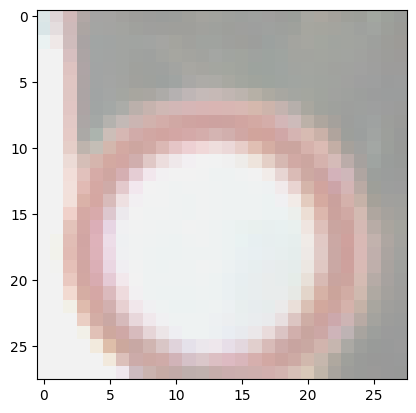

15 




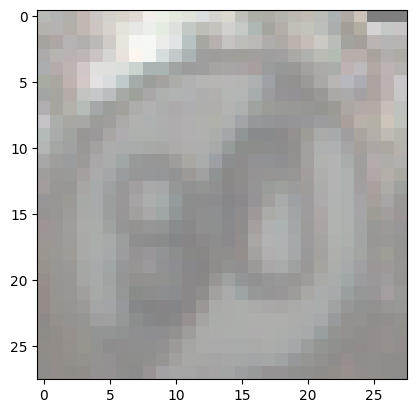

6 




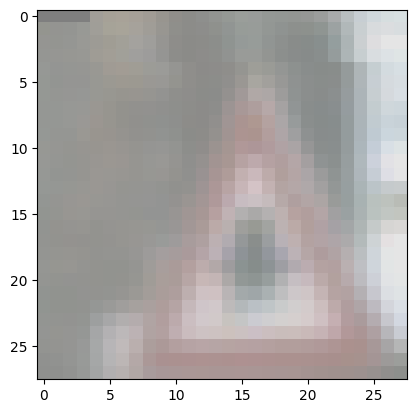

11 




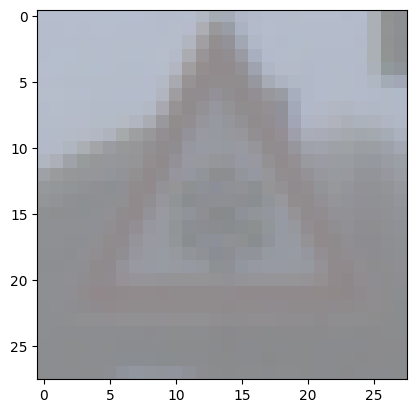

30 




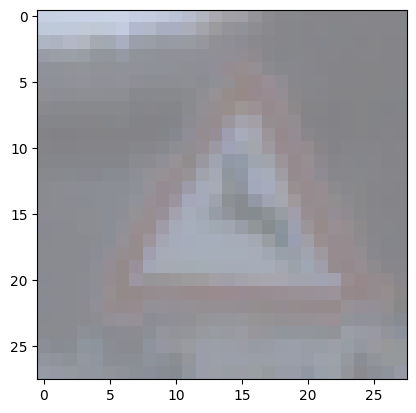

31 




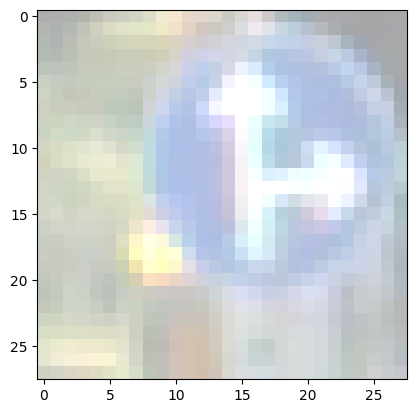

36 




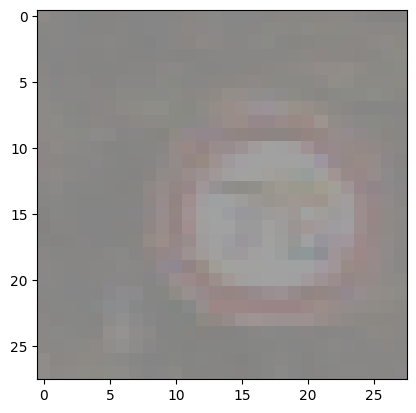

4 




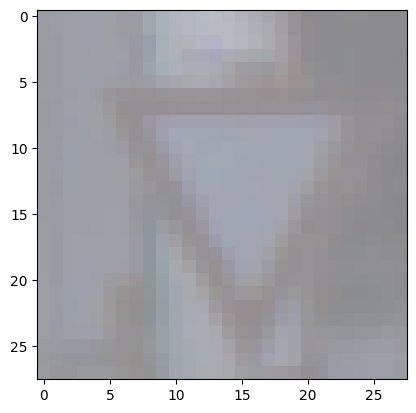

13 




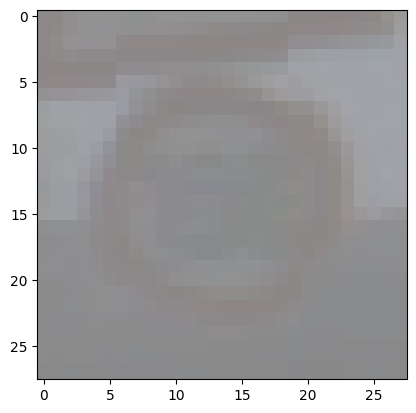

7 




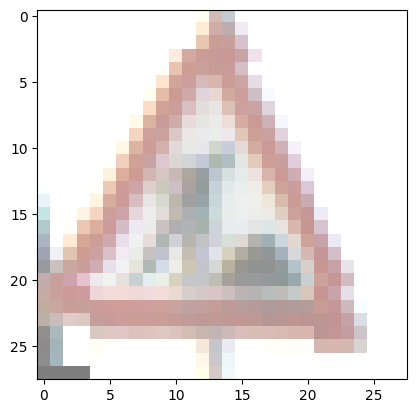

25 




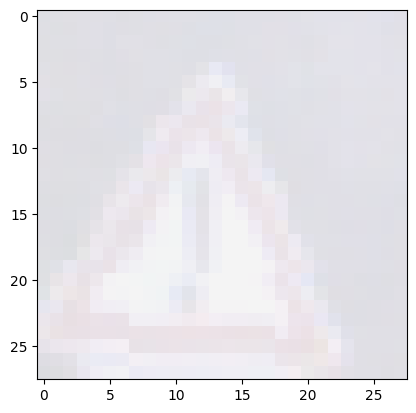

18 




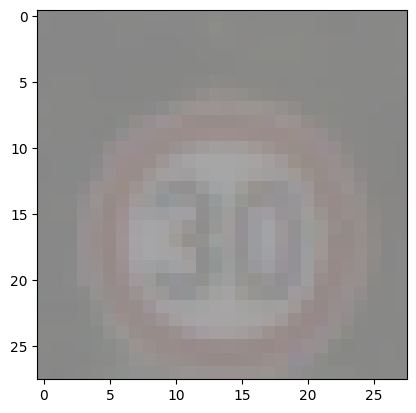

1 




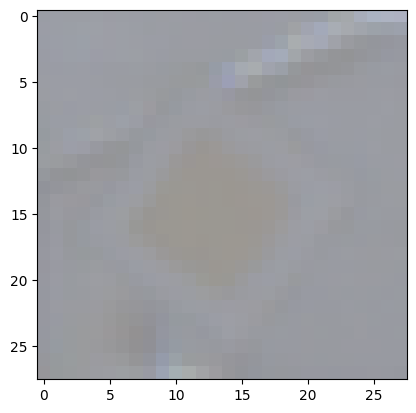

12 




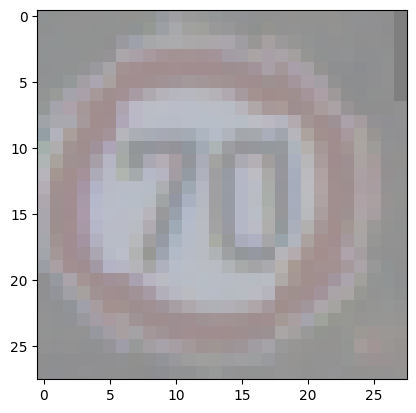

4 




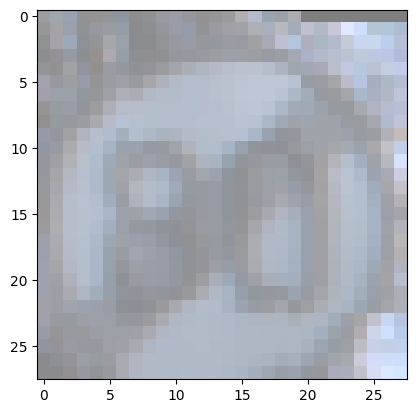

6 




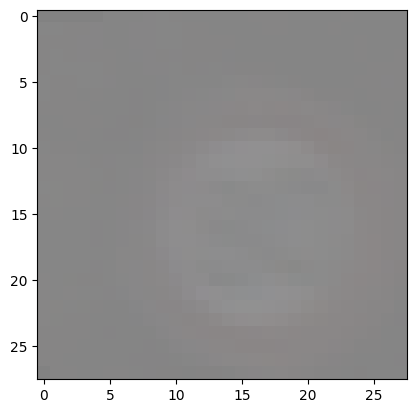

5 




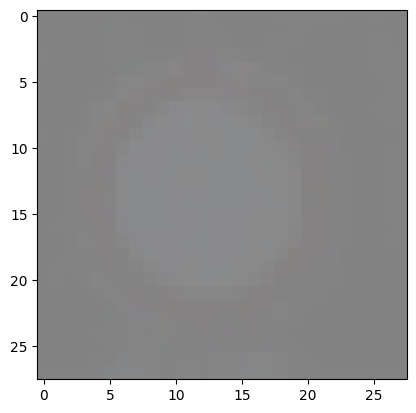

15 




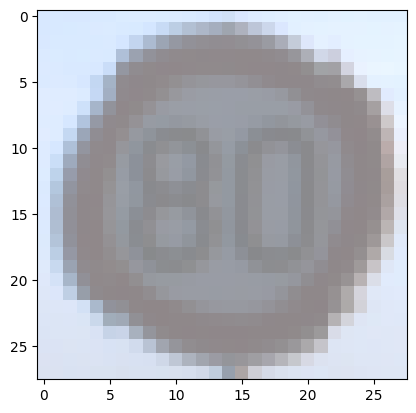

5 




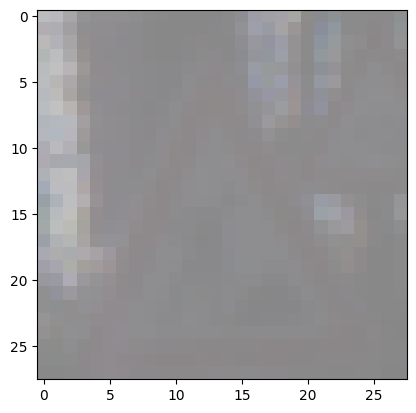

25 




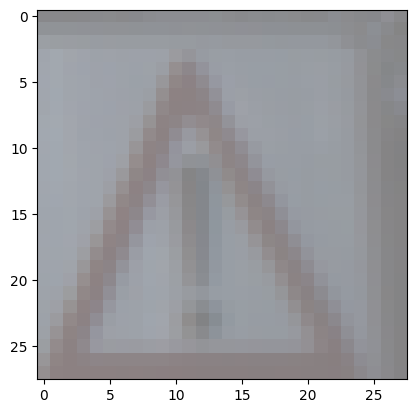

18 




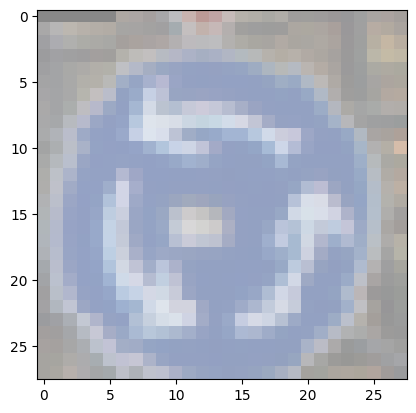

40 




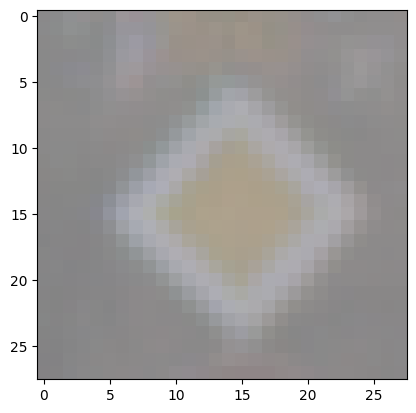

12 




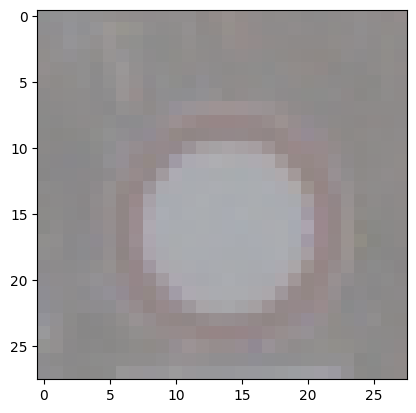

15 




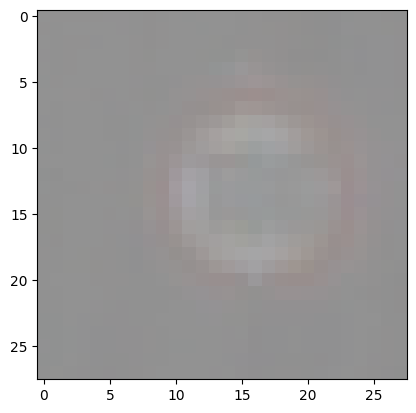

7 




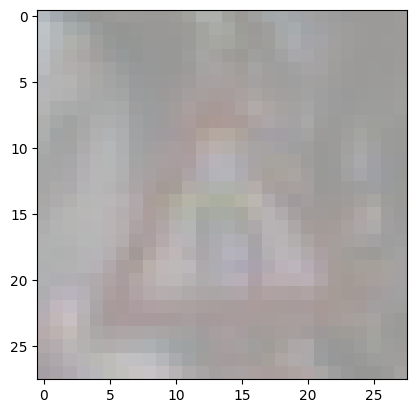

24 




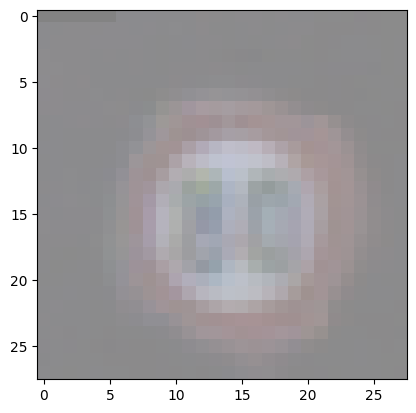

5 




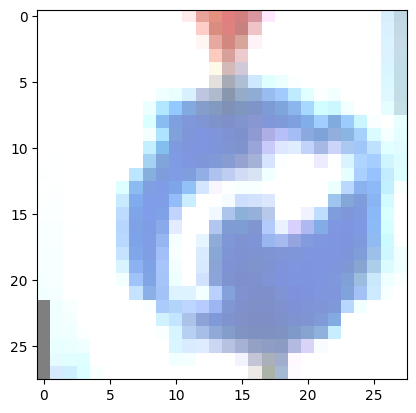

33 




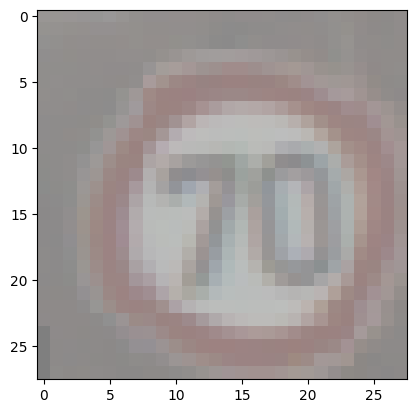

4 




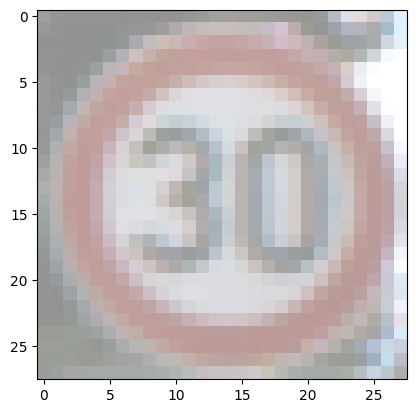

1 




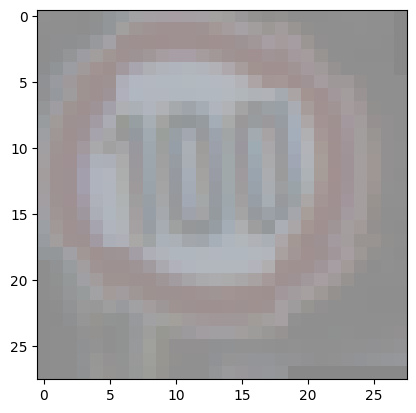

7 




In [11]:
for i in range(batch_size):
  imshow(images[i])
  print(labels[i].item(), "\n\n")


Define the neural network:

In [30]:
class Net(nn.Module):
    def __init__(self, img_size=28):
        super(Net, self).__init__()
        # 3 input channels (RGB), 64 output features, 5x5 kernal
        self.conv1 = nn.Conv2d(3, 64, 5)
        self.pool1 = nn.MaxPool2d(2, 2)     
        # 64 input features, 64 output feautres, 5x5 kernel
        self.conv2 = nn.Conv2d(64, 64, 5)
        self.pool2 = nn.MaxPool2d(2, 2)     
        # flattening 64x4x4 into a vector of size 1024
        self.fc = nn.Linear(1024, 43)

    def forward(self, x):
        # Apply conv1->ELU->pool1
        x = self.pool1(F.elu(self.conv1(x))) # 64x12x12
        # Apply conv2->ELU->pool2
        x = self.pool2(F.elu(self.conv2(x))) # 64x4x4
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = self.fc(x)
        return x

Instantiate the neural network and potentially move it to GPU:

In [31]:
net = Net()
if(gpu):
  net.to(device)
print(net)

Net(
  (conv1): Conv2d(3, 64, kernel_size=(5, 5), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=1024, out_features=43, bias=True)
)


Define loss and optimization algorithm:

In [32]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001, eps=0.1)

These lines can be used to continue training:

In [33]:
cont = False
if cont:
  net.load_state_dict(torch.load('traffic_simple'))

Do the training:

In [34]:
no_epochs = 200
for epoch in range(no_epochs):  # Loop over the dataset multiple times
    running_loss = 0.0
    for i, data in enumerate(generator_train, 0):
        # Get the inputs; data is a list of [inputs, labels]
        if (gpu):
          inputs, labels = data[0].to(device), data[1].to(device)
        else:
          inputs, labels = data
        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Print statistics
        reporting_interval = 100
        running_loss += loss.item()
        if i % reporting_interval == reporting_interval-1:  # Print every reporting_interval mini-batches
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / reporting_interval))
            running_loss = 0.0

print('Finished Training')

[1,   100] loss: 3.611
[1,   200] loss: 3.488
[1,   300] loss: 3.432
[2,   100] loss: 3.337
[2,   200] loss: 3.209
[2,   300] loss: 3.079
[3,   100] loss: 2.940
[3,   200] loss: 2.833
[3,   300] loss: 2.723
[4,   100] loss: 2.601
[4,   200] loss: 2.502
[4,   300] loss: 2.399
[5,   100] loss: 2.281
[5,   200] loss: 2.205
[5,   300] loss: 2.126
[6,   100] loss: 2.028
[6,   200] loss: 1.922
[6,   300] loss: 1.873
[7,   100] loss: 1.766
[7,   200] loss: 1.736
[7,   300] loss: 1.680
[8,   100] loss: 1.595
[8,   200] loss: 1.535
[8,   300] loss: 1.498
[9,   100] loss: 1.413
[9,   200] loss: 1.417
[9,   300] loss: 1.371
[10,   100] loss: 1.321
[10,   200] loss: 1.292
[10,   300] loss: 1.254
[11,   100] loss: 1.206
[11,   200] loss: 1.214
[11,   300] loss: 1.144
[12,   100] loss: 1.139
[12,   200] loss: 1.083
[12,   300] loss: 1.091
[13,   100] loss: 1.048
[13,   200] loss: 1.023
[13,   300] loss: 1.014
[14,   100] loss: 0.998
[14,   200] loss: 0.964
[14,   300] loss: 0.949
[15,   100] loss: 0

Evaluate on test set:

In [35]:
dataset_test = GTSRBTrafficSigns(train=False)
generator_test = torch.utils.data.DataLoader(dataset_test, batch_size=batch_size, shuffle=False, num_workers=4)
print("Number of test patterns:", dataset_test.__len__())

Using existing ./GTSRB/test
Number of test patterns: 12630


In [36]:
correct = 0
total = 0
with torch.no_grad():
    for data in generator_test:
        if (gpu):
          images, labels = data[0].to(device), data[1].to(device)
        else:
          images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on test images: %.2f %%' % (100 * correct / total))

Accuracy of the network on test images: 94.19 %


Save network:

In [37]:
torch.save(net.state_dict(), 'traffic_simple')